# W7 deck figures — what changed for the final talk

The W6 deck's figures are built by [`15_w6_visuals.ipynb`](15_w6_visuals.ipynb) and are unchanged.
This notebook holds only the figures **revised or added for W7**, so the W6 notebook stays a record
of what was presented in week 6 rather than being edited under it.

**Two revisions, both prompted by the same instinct — say what is actually known.**

1. **The tiles carry their spread** (slides 3 and 5). They reported bare means — 42% / 52% / 73% —
   with no indication of how much a single region-season varies around them. The prompt was the W7
   confidence work in [`06_analysis.ipynb`](06_analysis.ipynb): once a per-cell confidence *ranking*
   exists, presenting the mean alone understates what is known and overstates what one forecast is
   worth.

2. **The human ladder gains a second model family** (slide 5). All three of its learned rungs were
   the same estimator at stock settings, so the figure could not answer "was the learner at fault?"
   A ridge rung — added in [`08_human_cause.ipynb`](08_human_cause.ipynb) — beats the booster and
   still loses to the floor, which is a stronger result than the three-bar version showed.

Figures are written to `../img/` and consumed by `coursework/W7/MSDS696_W7_Deck.pptx` via
`coursework/W7/final_script.md`, which is the authoritative text.

**Section headings use slide numbers**, matching the deck and the script. The storyboard's beat
numbering was retired in W7.

In [1]:
import sys
from pathlib import Path

from IPython.display import Image

sys.path.insert(0, "../src")
import w6_visuals as wv
from config import ProjectConfig
from panel import RegionSeasonPanel

cfg = ProjectConfig()
IMG = Path("../img")
IMG.mkdir(exist_ok=True)

# Same panel object the analysis notebooks use, so a figure cannot drift from the
# numbers 06 reports.
panel = RegionSeasonPanel.load(cfg)
print(f"{panel.rsc.region.nunique()} regions x {panel.rsc.season.nunique()} seasons "
      f"| test split at season_year >= {cfg.test_start} | shares window k={cfg.shares_k}")

105 regions x 4 seasons | test split at season_year >= 2010 | shares window k=7


## Beat 3 — the Tier-1 tiles, now carrying their spread

Three predictors of a region-season's next cause mix, scored on the held-out tail: the national
average mix, an even split, and the region's own k=7 trailing history. The tile value is
`1 - TVD`, which on a simplex is exactly the overlap between the predicted and actual composition —
so "share of the burned-acre composition placed on the right cause" is literal.

**What is new is the span beneath each bar: the middle half (p25–p75) of the per-cell
distribution.** The headline is an average over 3,949 held-out region-seasons; a planner receives
one of them. A bare mean invites the reading that every region-season lands near 73%, and they do
not.

**The span is acre-weighted, matching the headline.** Unweighted percentiles were tried first and
produced a figure that reads as a mistake — the national tile came out at a 42% headline against a
50–79% range, because that predictor fails hardest on exactly the big-burn cells the acre weighting
is dominated by, while doing adequately on the many small ones. Both numbers were correct and the
pair was unreadable. One denominator throughout is the same rule the spoken script applies to every
share it quotes.

**It is a spread across region-seasons, not a confidence interval on the mean.** The figure's drawn
label says "typical range" for that reason. No inferential claim is being made, and the notes forbid
calling it one.

  national  42.0%   typical range 21%-61%   median 36%
  naive     51.5%   typical range 36%-67%   median 47%
  history   73.4%   typical range 58%-91%   median 80%

  3,949 held-out region-seasons, season_year >= 2010, k=7


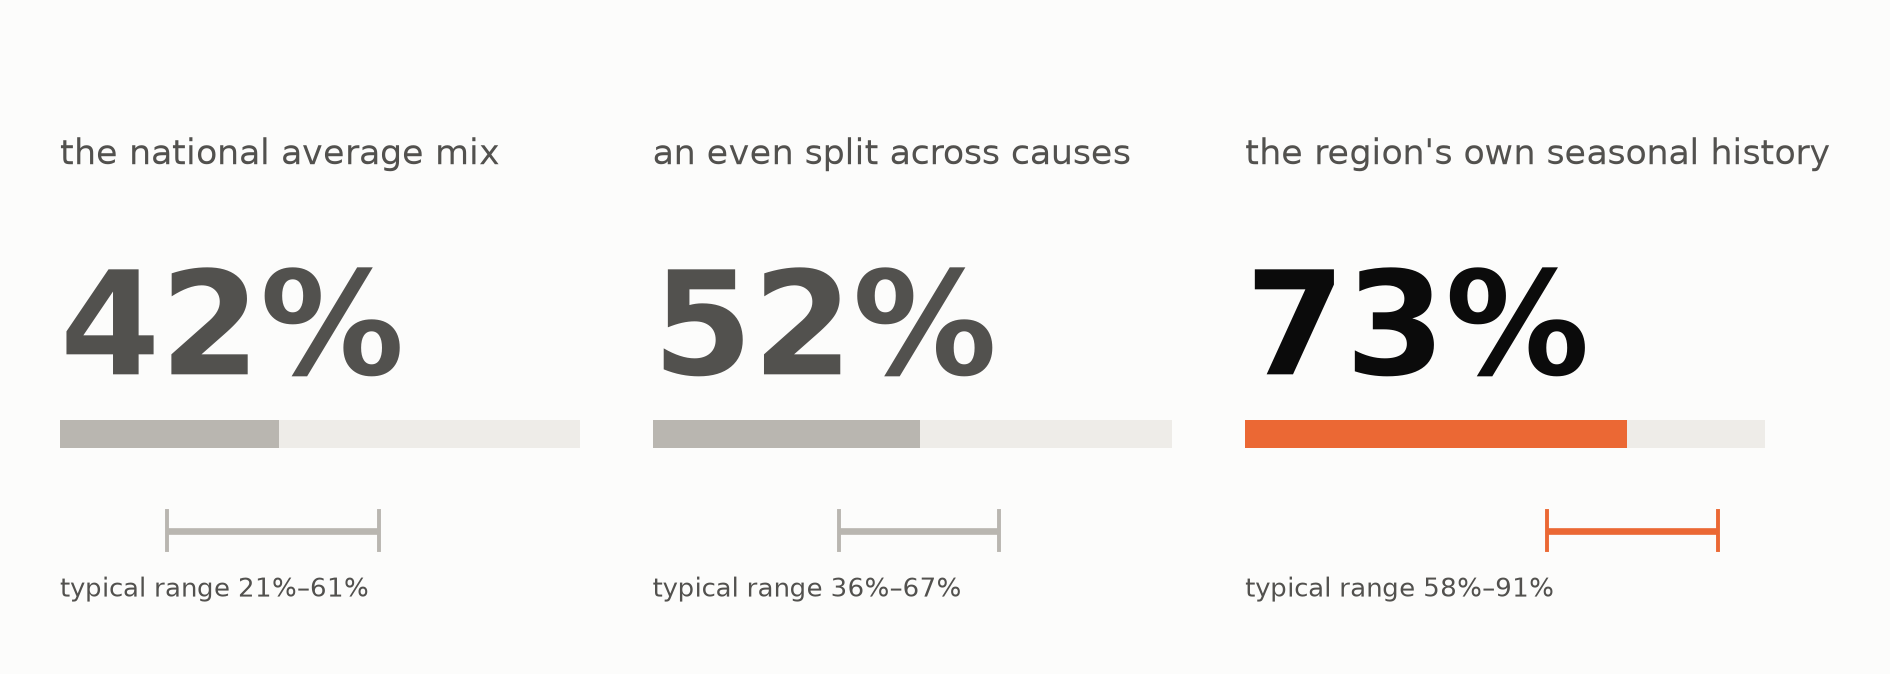

In [2]:
tiles = wv.plot_tier1_tiles(panel, IMG / "w6_tier1_tiles.png", k=cfg.shares_k)

for key in ("national", "naive", "history"):
    print(f"  {key:9s} {tiles[f'{key}_correct']:.1%}   "
          f"typical range {tiles[f'{key}_p25']:.0%}-{tiles[f'{key}_p75']:.0%}   "
          f"median {tiles[f'{key}_p50']:.0%}")
print(f"\n  {tiles['n_cells']:,} held-out region-seasons, season_year >= {tiles['test_start']}, "
      f"k={tiles['k']}")

Image(filename=tiles["out_path"], width=980)

**Finding.** The comparison survives the added honesty, and is sharper for it. The region's own
history spans **58%–91%** where the national average mix spans **21%–61%** — the two barely overlap,
so history is not merely better on average, it is better across most of the distribution.

The national tile is the one the spread most changes. Its headline of 42% is not a middling result
evenly spread; it reaches down to **21%** at the first quartile. That is beat 2's bimodality
reappearing as forecast error: a national average describes almost no individual region, so applying
it to a specific region-season fails badly and often.

**What the span does not say.** It is variation across region-seasons, not uncertainty about the
mean, and it does not identify *which* cells land at the bottom. That question is answered
separately in [`06_analysis.ipynb`](06_analysis.ipynb): a cell's own pre-season history dispersion
predicts its error (Spearman +0.484, 33 SD above a shuffled control), so the low end of this span is
substantially anticipated rather than random.

## Both tile figures: "history" → "seasonal history"

The winning tile on beats 3 and 5 was labelled *the region's own history*, which does not say that
the series is **per season**. `TrailingMean` is called with `group_keys=("region", "season")`, so
Klamath summer sees only prior Klamath summers, and **k=7 is seven prior same-season occurrences —
about seven years back, not seven consecutive seasons.**

Pooling the four seasons would average a region's human-dominated winter against its
lightning-dominated summer and predict neither, which is the opening beat's seasonality returning as
a modelling error. The label now says *seasonal history* so the figure carries that itself.

Only the two Level III tile figures changed. The hex-grain ladders group by hex and keep their own
wording.

## Beat 5 — the Human tiles, split by confidence

The same three-tile form one level down, on the 11 human sub-causes. **A p25–p75 span cannot be
drawn here**: the value is a top-1 hit rate, which is 0/1 per cell, so its quartiles are 0 and 1 and
an interval would say nothing.

The honest equivalent is to report the hit rate **at each end of the signal that predicts it**. The
winning tile now carries a single line: 68% where the region-season's own pre-season history has
been settled, 43% where it has been swinging — quartiles of the same dispersion measure used in
[`06_analysis.ipynb`](06_analysis.ipynb), on the same window, shift and `(region, season)` grouping
as the prediction, so it stays strictly pre-season information.

**The spread is wider here than on Tier 1** (25 points against 21), which is the useful part: this
is the weaker branch, and its failures turn out to be anticipated rather than random.

{'steadiest_top1': 0.6816, 'volatile_top1': 0.4348, 'split_n': 3844, 'n_cells': 3850, 'n_classes': 11, 'k': 7, 'leading_cause': 'Arson/incendiarism', 'history_top1': 0.5405, 'national_top1': 0.164, 'chance_top1': 0.0909, 'history_tvd': 0.4887, 'national_tvd': 0.6431, 'best': 'history'}


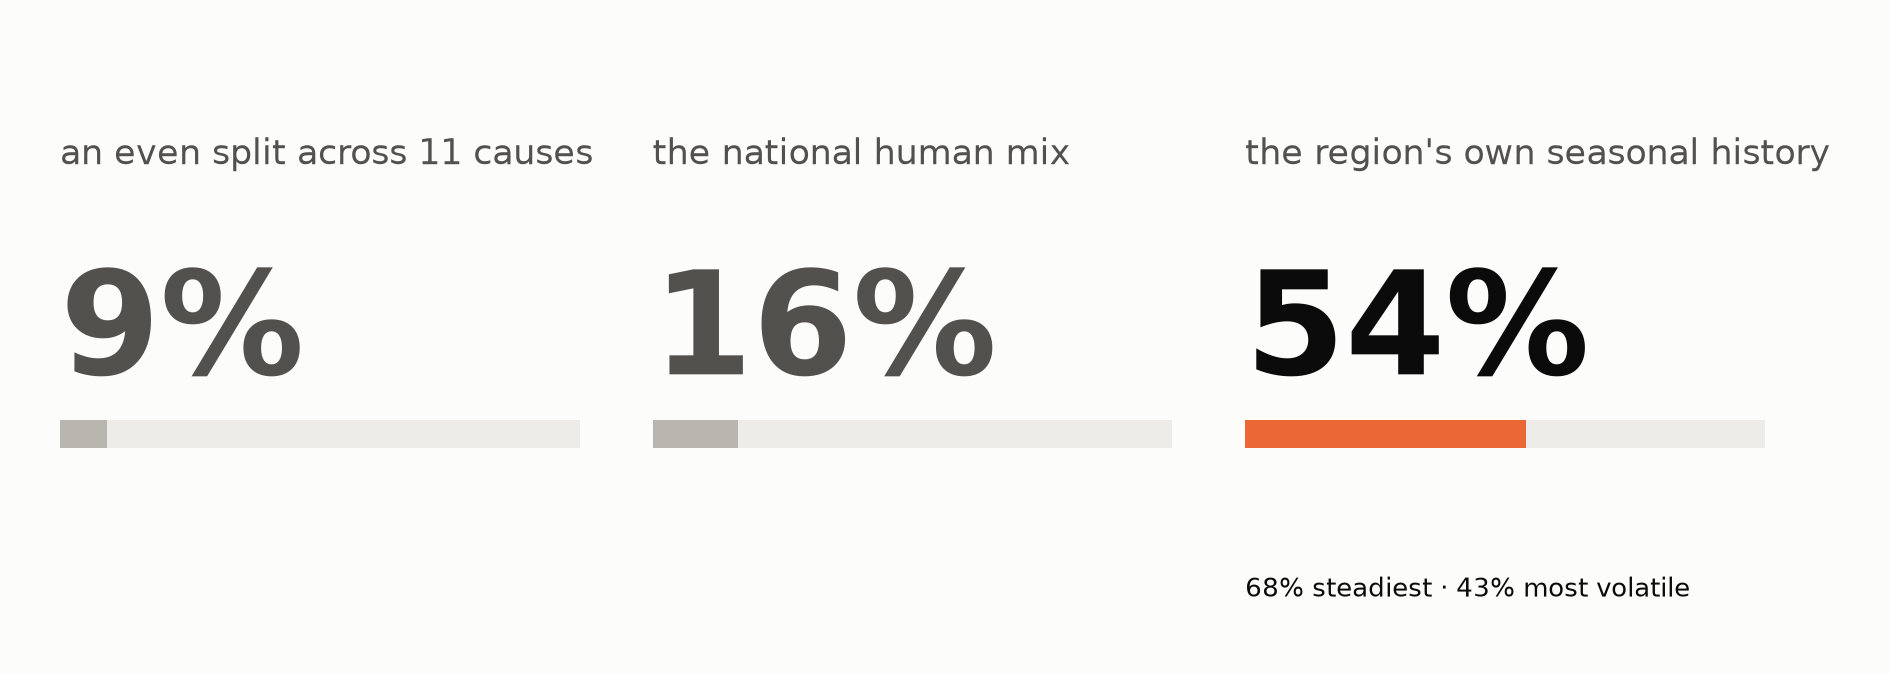

In [3]:
human = wv.plot_human_tiles(panel, IMG / "w6_human_tiles.png")
print({k: (round(v, 4) if isinstance(v, float) else v)
       for k, v in human.items() if k != "out_path"})

Image(filename=human["out_path"], width=980)

**Finding.** Both tile figures now carry their own range, in the encoding each metric permits — a
p25–p75 span on beat 3, a stated steadiest/most-volatile split on beat 5. Neither is a confidence
interval and the notes forbid calling them one.

The tier-2 split is the wider of the two: **68.2% against 43.5%**, 24.7 points, on 3,844 held-out
cells. Tier 1's equivalent quartile spread is 21 points. The branch with the weaker headline has the
stronger confidence signal, which is what makes the ranked human profile shippable with a flag
rather than shippable with a caveat.

## Slide 5 — the human ladder, with a second model family

The W6 ladder had three rungs and **all three learned ones were the same estimator**:
`SimplexRegressor`, which is `HistGradientBoostingRegressor` at stock settings. That left the
figure open to a challenge it could not answer on its own — *was gradient boosting simply the wrong
learner?* — and made a headline about one model read as a claim about learned models generally.

The linear rung added in [`08_human_cause.ipynb`](08_human_cause.ipynb) settles it, and the answer
is more interesting than a second identical failure: **ridge beats the booster.** Same features,
same forward-chaining split, same acre weights, same held-out cells, same simplex projection — only
the learner changed. The booster was paying a variance cost on a panel that is small and wide for it
(~5,300 training cells, 23 features, 11 correlated targets), and a high-bias learner recovers about
five points of top-1.

It still stops short of the floor. That is the bar worth drawing: a second family, handed the exact
quantity the floor averages, landing 1.9 points below a trailing mean.

**Only the history-aware ridge rung is plotted.** Ridge on the coarse fingerprints scores 0.3567
against gradient boosting's 0.3566 — two bars of identical length both reading "36%" would cost a
beat of reading time to discover they say the same thing. The complete five-rung table stays in
notebook 08.

**The floor's label also changes here**, from *the region's own history* to *the region's own
seasonal history*, matching the tiles above. Same quantity, and it should not carry two names two
slides apart.

                                               label     tvd    top1
key                                                                 
floor              the region's own seasonal history  0.4887  0.5405
coarse         gradient boosting on region character  0.5877  0.3566
history_aware  gradient boosting, given that history  0.5536  0.4748
ridge_history              ridge, given that history  0.5366  0.5215

held-out cells: 3,846   train: 5,312
cross-check vs 08_human_cause.ipynb: all four rungs match

  0.540  beats floor  the region's own seasonal history
  0.521  below floor  ridge, given that history
  0.475  below floor  gradient boosting, given that history
  0.357  below floor  gradient boosting on region character


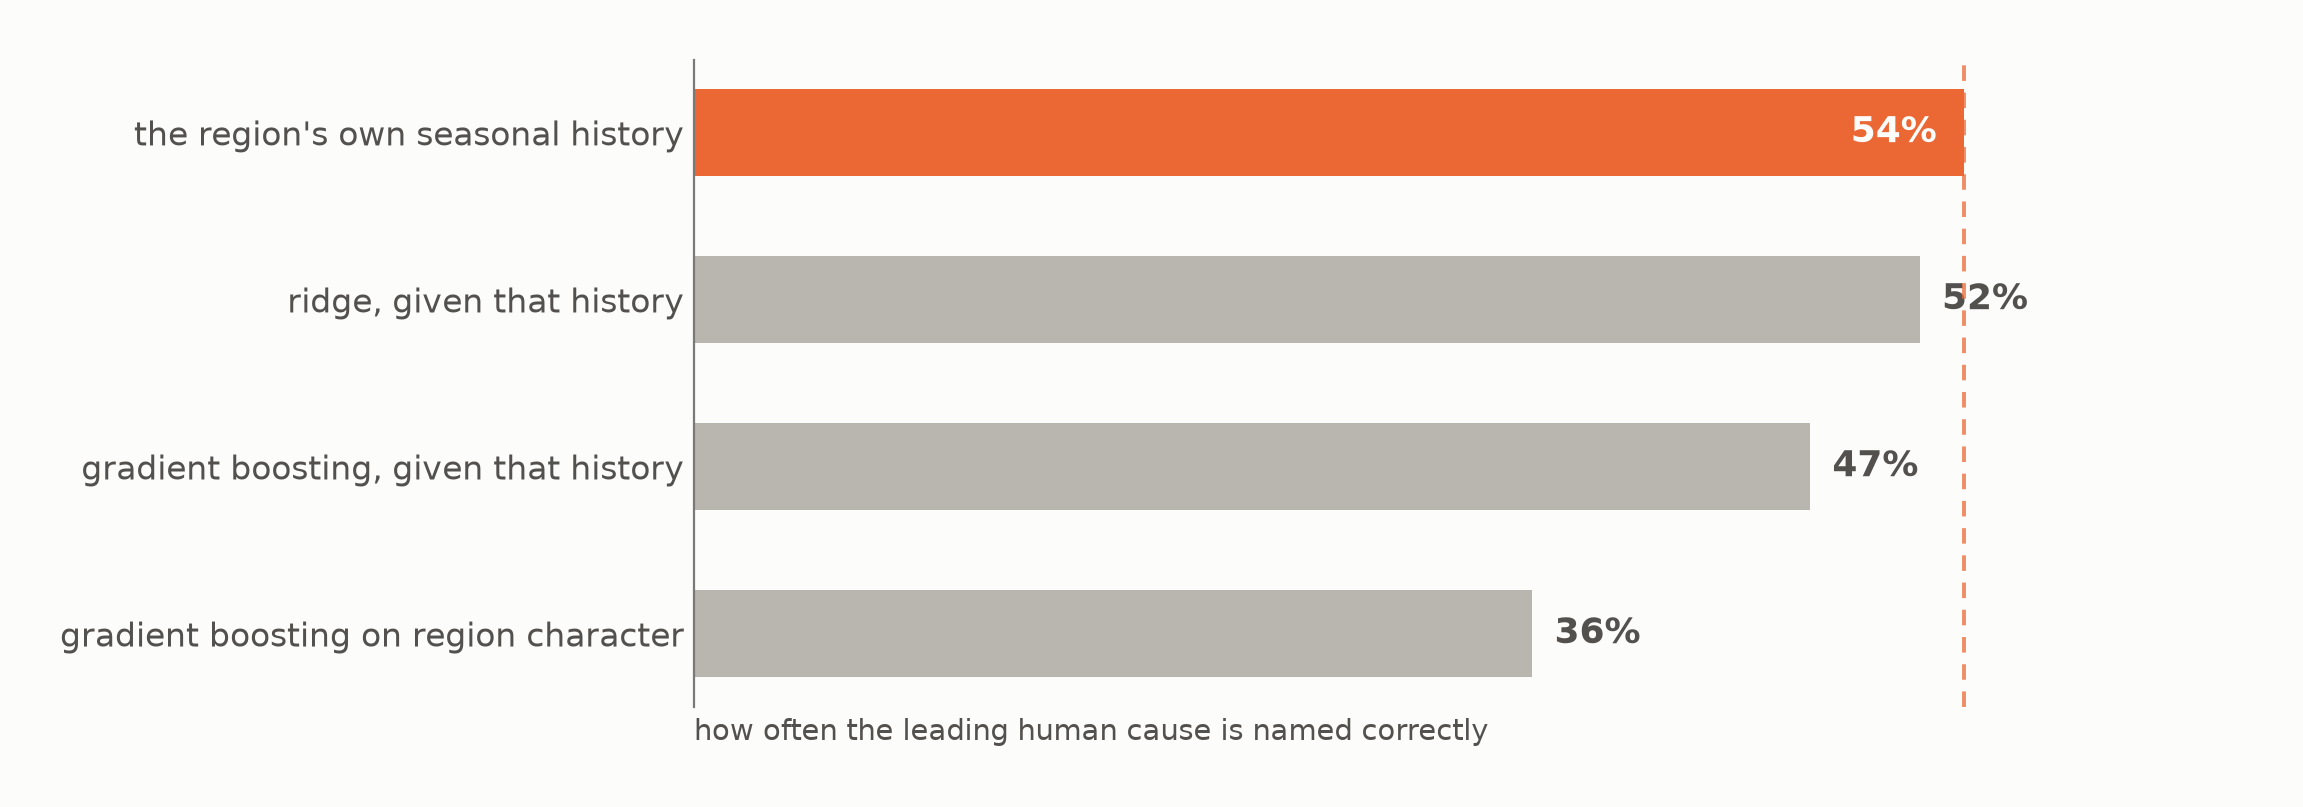

In [4]:
# ~2 min: refits 22 gradient-boosted regressors plus 11 near-instant ridges. include_ridge=True
# is the default; pass False to reproduce the W6 three-rung figure.
rungs = wv.human_rung_scores(panel, cfg=cfg)
print(rungs.round(4).to_string())
print(f"\nheld-out cells: {rungs.attrs['n_test']:,}   train: {rungs.attrs['n_train']:,}")

# These must match 08_human_cause.ipynb exactly -- two independently written code paths over the
# same data. A mismatch means the figure has drifted from the notebook that reports it, which is
# the whole failure mode `human_rung_scores` exists to prevent.
EXPECTED = {"floor": (0.4887, 0.5405), "coarse": (0.5877, 0.3566),
            "history_aware": (0.5536, 0.4748), "ridge_history": (0.5366, 0.5215)}
for key, (tvd_x, top1_x) in EXPECTED.items():
    assert abs(rungs.loc[key, "tvd"] - tvd_x) < 2e-3, f"{key} TVD drifted from notebook 08"
    assert abs(rungs.loc[key, "top1"] - top1_x) < 2e-3, f"{key} top-1 drifted from notebook 08"
print("cross-check vs 08_human_cause.ipynb: all four rungs match")

lad = wv.plot_ablation_ladder(
    rungs["label"], rungs["top1"], IMG / "w6_human_ladder.png",
    xlabel="how often the leading human cause is named correctly",
    sort=True)
print()
for lbl, val, ok in zip(lad["labels"], lad["values"], lad["beats_floor"]):
    print(f"  {val:.3f}  {'beats floor' if ok else 'below floor'}  {lbl}")

Image(filename=lad["out_path"], width=980)

**Finding.** Four bars, two model families, and the trailing mean still on top. The ordering is
**54% / 52% / 47% / 36%**, and the middle pair is what the extra rung buys: ridge given the history
reaches **52.2%** against gradient boosting's **47.5%**, so the figure now shows a learned rung
getting genuinely close before falling short, rather than three losses at a distance.

That is a better argument than the W6 version made. A model that loses by 18 points invites "you
used the wrong model"; a model that loses by 1.9 after a change of family — with the flat `alpha`
sweep in notebook 08 showing four orders of magnitude of regularization moving top-1 not at all —
looks like a ceiling.

**Two bars are not on the figure and should be named if asked.** Ridge on the coarse fingerprints
(35.67%) is omitted as a visual duplicate of the gradient-boosting coarse rung (35.66%). And no
hyperparameter search over the booster was run; the flat ridge sweep is the reason for thinking it
unpromising, not proof that it is.

**Aspect ratio note for the deck.** `plot_ablation_ladder` keeps its `figsize=(10.0, 4.2)` default,
so the fourth bar makes the plot area taller relative to its width than the three-bar version. The
slide sizes this figure to the full frame width to match the neighbouring human tiles, so the
rendered image is slightly taller than it was — worth a look when the deck is next opened.

## Slide 16 — the recommendation, retitled

Two lines changed on this figure and neither is about the three products.

The bold closing line was **"Stop targeting how big it gets. Target where it starts."** — the deck's W6 title, which slide 0 no longer carries. With the title now reading *Rank the ground, not the fire*, the figure was asserting a phrasing that appeared nowhere else in the talk. It now repeats the title verbatim, so the deck opens and closes on the same words.

The subtitle was **"rank on all three — the order is trustworthy, the acre level much less so."** That is the boundary, and it is also exactly what the spoken closer says (*"trust the order, not the number"*) — printing it here duplicated the narration inside the same ten seconds. The subtitle now states the finding the recommendation rests on: **where fires start is predictable; how big they get, before the season, is not.** Nothing else on the figure says that, and it is the split every null and every win in the deck hangs off.


  classes: ['NATURAL', 'HUMAN', 'UNKNOWN']
  shares:  ['58.9%', '22.7%', '18.5%']
  grains:  ['hex-season', 'ecoregion-season', 'ecoregion-season']


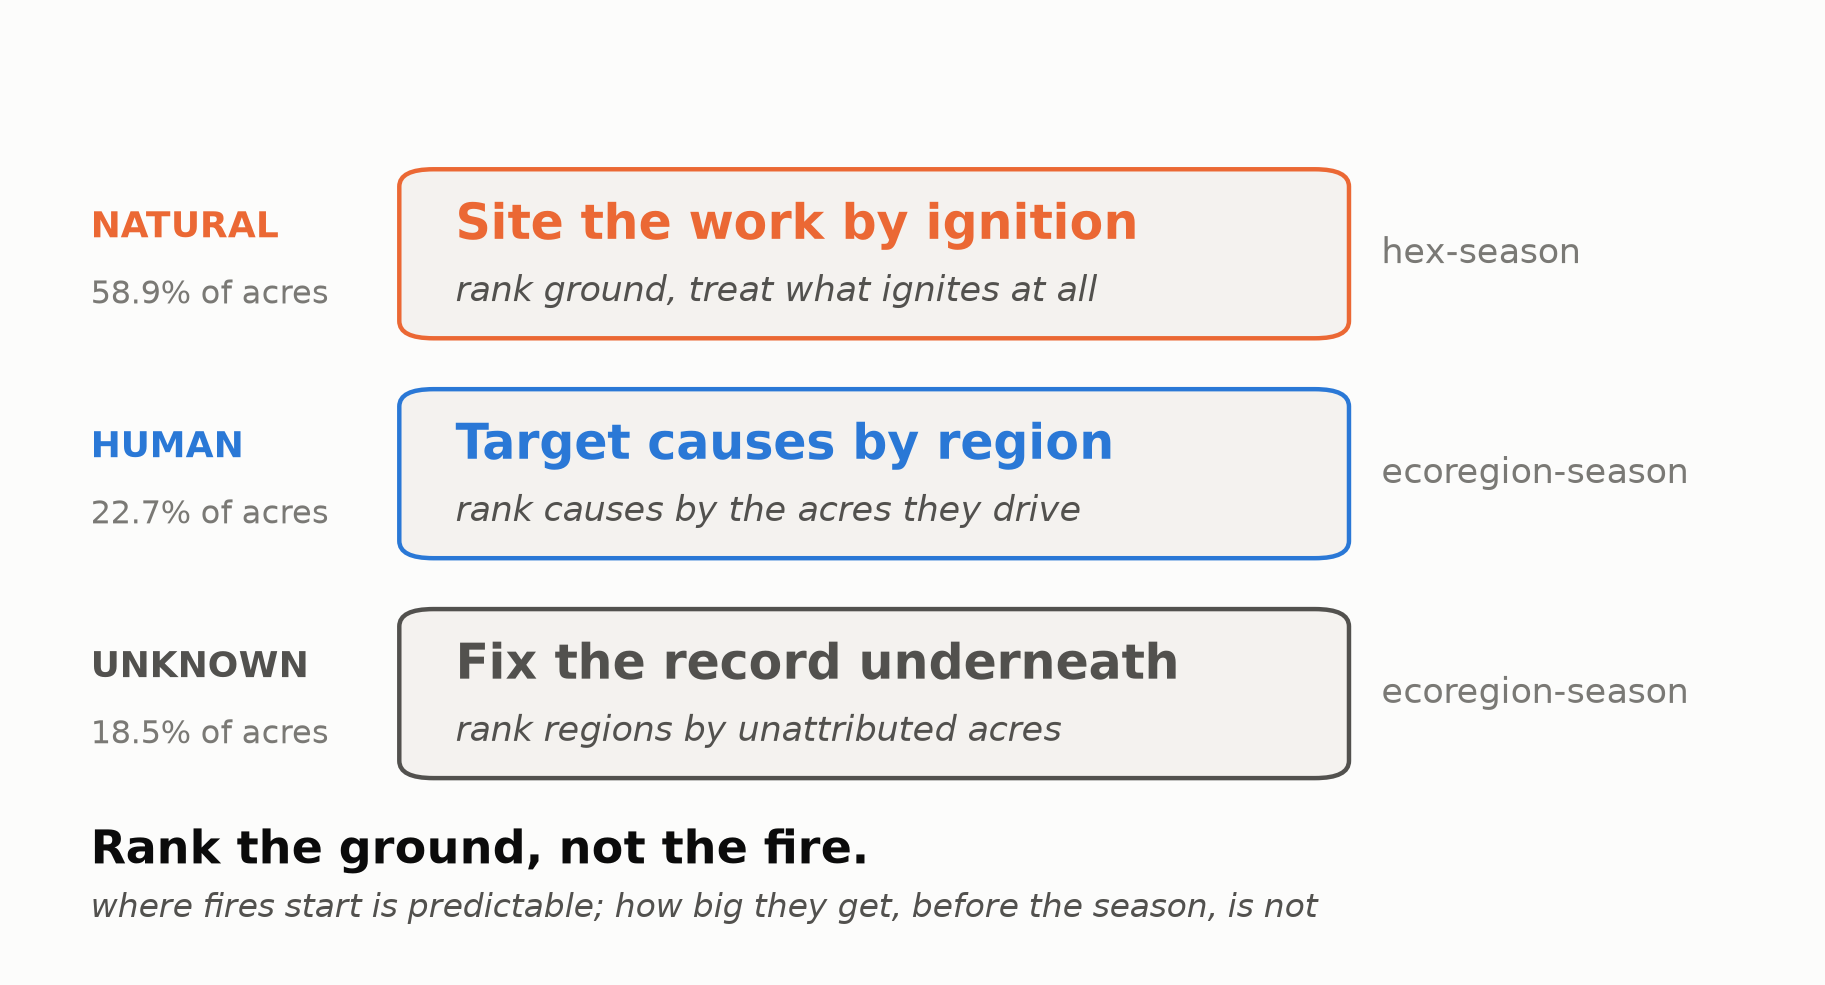

In [5]:
rec = wv.plot_recommendation(IMG / "w6_recommendation.png")
print(f"  classes: {rec['classes']}")
print(f"  shares:  {[f'{v:.1%}' for v in rec['shares']]}")
print(f"  grains:  {rec['grains']}")

Image(filename=rec["out_path"], width=980)

**Finding.** The figure carries the bookend and the SAY carries the boundary, rather than both carrying both. Slide 0 and slide 16 now print *Rank the ground, not the fire* — a visual bookend that costs no speaking time — while the spoken closer says the thing nothing on screen says: trust the order, not the number.

The three product rows are unchanged. The shares still sum over the Tier-1 classes (58.9 / 22.7 / 18.5) and each row still names its grain, because the grain difference between the ignition surface and the two ecoregion products is the one structural fact a planner has to carry away.


## Slide 17 — the data sources, as a stack rather than a list

A new closing slide. The talk's method is that **FPA-FOD is the spine and everything else is joined onto it**, and nothing in the deck said so — the ecoregions arrive on slide 2, the perimeters are implied by slide 7's attribution answer, and the covariates appear on slide 10 as things that failed. An audience had no way to see that one record underlies all of it.

A flat bibliography would present five equal datasets and lose exactly that. So the layout is a stack: the base record in its own emphasized band, a rule, then the four joined layers, each labelled with **what it contributed and why the base record needed it**.

Every row carries author, year and a resolvable identifier — DOI where one exists, the canonical URL otherwise. Access dates, file names and API endpoints stay in the repository; they are unreadable from ten feet away and nobody asks for them.


  base:   FPA-FOD, 6th edition
  joined: EPA Level III ecoregions
  joined: MTBS burned-area perimeters
  joined: TerraClimate
  joined: MODIS MOD13A1 v6.1


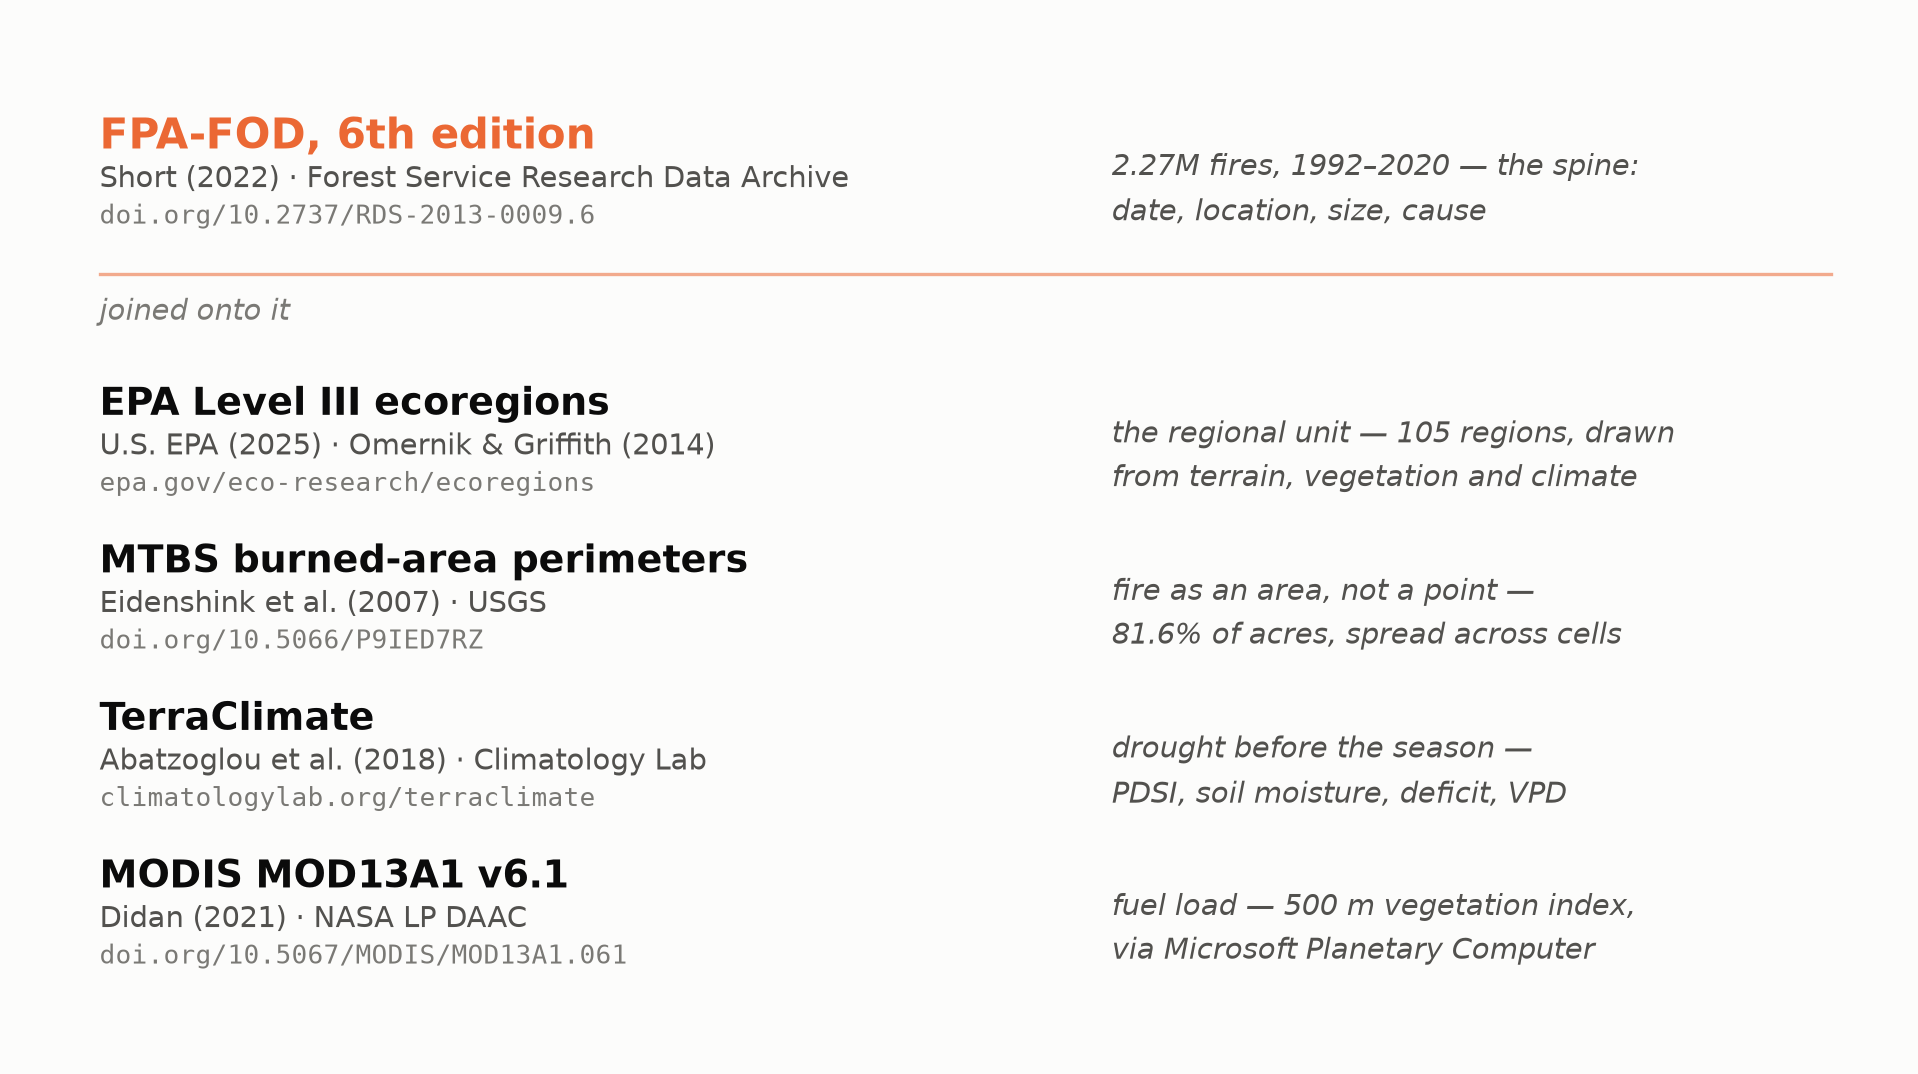

In [6]:
src = wv.plot_data_sources(IMG / "w6_data_sources.png")
print(f"  base:   {src['base']}")
for layer in src["layers"]:
    print(f"  joined: {layer}")

Image(filename=src["out_path"], width=980)

**Finding.** Two of the four joined layers — TerraClimate and MODIS — produced nulls on the ignition branches, and they stay on the slide for that reason. They are what make slides 10–12 a *measured* result rather than an untested assumption, and a reference slide that listed only the sources that worked would misrepresent the method.

The Planetary Computer appears as an access route, not an origin: MODIS is NASA's, and the Planetary Computer is how it was fetched without Earthdata credentials. LANDFIRE is absent deliberately — pre-rejected for this panel on interannual variance, which is a decision rather than an oversight.
